In [68]:
import os
import pandas as pd
import numpy as np
from scipy import stats

class Buoy:
    """
    Class for processing NOAA buoy data from various file formats and years.
    Handles different header formats, year representations, and column variations.
    Also provides methods for wind extrapolation, extreme event identification,
    and simulation of extreme wind shear and gusts.
    """
    
    def __init__(self, directory):
        """
        Initialize the Buoy data processor.
        
        Parameters:
        -----------
        directory : str
            Path to the directory containing NOAA buoy data files (.txt)
        """
        self.directory = directory
        self.headers = [
            "YYYY (year)", "MM (month)", "DD (day)", "hh (hour)", "mm (minute)", 
            "WDIR (degT)", "WSPD (m/s)", "GST (m/s)", "WVHT (m)", "DPD (sec)", 
            "APD (sec)", "MWD (deg)", "PRES (hPa)", "ATMP (degC)", "WTMP (degC)", 
            "DEWP (degC)", "VIS (nmi)", "TIDE (ft)"
        ]
        self.data = None
        self.dataframes = []
    
    def _extract_year_from_filename(self, filename):
        """Extract the year from a filename like '44009h2007.txt'"""
        filename_year = None
        if 'h' in filename and filename.endswith('.txt'):
            try:
                year_part = filename.split('h')[1].split('.')[0]
                if len(year_part) == 4 and year_part.isdigit():
                    filename_year = int(year_part)
            except:
                pass
        return filename_year
    
    def _determine_file_format(self, header_lines, filename):
        """
        Determine the format of the file based on its header lines.
        Returns a tuple of (format_type, skiprows)
        """
        if len(header_lines) < 1:
            return 'unknown', 1
            
        first_line = header_lines[0]
        second_line = header_lines[1] if len(header_lines) > 1 else ""
        
        # Determine the format of the file based on the header
        if '#YY' in first_line and '#yr' in second_line:
            return 'double_with_header', 2
        elif ('YY' in first_line) and ('yr' not in second_line):
            return 'double', 1
        elif 'YYYY' in first_line and 'TIDE' not in first_line:
            return 'four', 1
        elif 'YYYY' in first_line and 'TIDE' in first_line and 'mm' not in first_line:
            return 'four_tide', 1
        elif 'YYYY' in first_line and 'mm' in first_line:
            if any(unit in second_line for unit in ['yr', 'mo', 'degT']):
                return 'full', 2
            else:
                return 'full', 1
        else:
            return 'unknown', 1
    
    def _process_single_file(self, filepath, filename):
        """Process a single buoy data file and return a DataFrame"""
        filename_year = self._extract_year_from_filename(filename)
        
        with open(filepath, 'r') as file:
            header_lines = []
            for i in range(5):
                line = file.readline().strip()
                if line:
                    header_lines.append(line)
                if len(header_lines) >= 2:
                    break
        
        year_format, skiprows = self._determine_file_format(header_lines, filename)
        print(f"Processing {filename}: Format '{year_format}', skipping {skiprows} rows")
        
        df = pd.read_csv(filepath, sep='\s+', skiprows=skiprows, header=None, on_bad_lines='skip')
        
        if df.empty:
            print(f"Skipping {filename}: Empty data")
            return None
            
        first_year_in_file = df[0].iloc[0] if len(df) > 0 else None
        
        if first_year_in_file is not None:
            if len(str(int(first_year_in_file))) <= 2:
                df[0] = df[0].apply(lambda x: 1900 + int(x) if int(x) >= 80 else 2000 + int(x))
            elif filename_year is not None and abs(int(first_year_in_file) - filename_year) > 100:
                print(f"Correcting year in {filename}: from {first_year_in_file} to {filename_year}")
                df[0] = filename_year
        
        first_line = header_lines[0] if header_lines else ""
        
        if 'mm' not in first_line:
            df.insert(4, 'mm', 0)
        
        pres_col_index = 12
        if 'PRES' not in first_line and 'BAR' in first_line:
            pass
        elif 'PRES' not in first_line and 'BAR' not in first_line:
            df.insert(pres_col_index, 'PRES', None)
            
        if 'TIDE' not in first_line:
            df['TIDE'] = None
        
        if 'WD' in first_line and 'WDIR' not in first_line:
            col_index = 5
            df.rename(columns={df.columns[col_index]: 'WDIR'}, inplace=True)
        
        if df.shape[1] > len(self.headers):
            df = df.iloc[:, :len(self.headers)]
        elif df.shape[1] < len(self.headers):
            for _ in range(len(self.headers) - df.shape[1]):
                df[len(df.columns)] = None
        
        df.columns = self.headers
        
        df["YYYY (year)"] = df["YYYY (year)"].apply(
            lambda x: int(x) if isinstance(x, (int, float)) and 1984 <= int(x) <= 2025 else filename_year
        )
        
        print(f"Processed {filename} with {len(df)} rows, year range: {df['YYYY (year)'].min()}-{df['YYYY (year)'].max()}")
        return df
    
    def process_files(self):
        """Process all buoy data files in the directory"""
        # Get the list of files and sort them
        files = sorted([f for f in os.listdir(self.directory) if f.endswith('.txt')])
        
        # Process each file
        for filename in files:
            filepath = os.path.join(self.directory, filename)
            
            try:
                df = self._process_single_file(filepath, filename)
                if df is not None:
                    self.dataframes.append(df)
            except Exception as e:
                print(f"Error processing {filename}: {str(e)}")
                continue
        
        # Combine all DataFrames into a single DataFrame
        if self.dataframes:
            self.data = pd.concat(self.dataframes, ignore_index=True)
            
            # Ensure YYYY column is always integer
            self.data["YYYY (year)"] = pd.to_numeric(self.data["YYYY (year)"], 
                                                   errors='coerce').fillna(2000).astype(int)
            
            # Sort the dataframe by year, month, day, hour, minute
            self.data = self.data.sort_values(
                by=["YYYY (year)", "MM (month)", "DD (day)", "hh (hour)", "mm (minute)"]
            )
            
            # Reset the index after sorting
            self.data = self.data.reset_index(drop=True)
            
            # Display summary
            print("\nCombined DataFrame:")
            print(f"Total rows: {len(self.data)}")
            print(f"Year range: {self.data['YYYY (year)'].min()} - {self.data['YYYY (year)'].max()}")
            return self.data
        else:
            print("No valid data found in the directory")
            return None
    
    def save_data(self, output_path):
        """Save the combined data to a CSV file"""
        if self.data is not None:
            self.data.to_csv(output_path, index=False)
            print(f"Data saved to {output_path}")
        else:
            print("No data to save. Run process_files() first.")
    
    def extrapolate_to_turbine_height(self, target_height=150, reference_height=10, alpha=None):
        """
        Extrapolate wind speeds to turbine height using power law.
        
        Parameters:
        -----------
        target_height : float
            Target height for extrapolation (m), typically turbine hub height
        reference_height : float
            Reference height of measurements (m), typically 10m for buoy data
        alpha : float or None
            Wind shear exponent. If None, it will be calculated from the data
            
        Returns:
        --------
        DataFrame with added columns for height-adjusted wind speed and gust
        """
        # Create a copy to avoid modifying the original data
        df = self.data.copy()
        
        # Calculate wind shear exponent if not provided
        if alpha is None:
            # Default value - can be refined with atmospheric stability
            alpha = 0.14  # Neutral stability over open water
        
        # Apply the power law to extrapolate wind speed to turbine height
        height_ratio = target_height / reference_height
        df['WSPD_150m'] = df['WSPD (m/s)'] * (height_ratio ** alpha)
        df['GST_150m'] = df['GST (m/s)'] * (height_ratio ** alpha)
        
        return df

    def calculate_wind_shear(self, heights=[10, 50, 100, 150], base_height=10):
        """
        Calculate wind shear parameters across multiple heights.
        
        Parameters:
        -----------
        heights : list
            Heights at which to calculate wind speeds (m)
        base_height : float
            Reference height of original measurements
            
        Returns:
        --------
        DataFrame with added columns for wind shear coefficient and speeds at different heights
        """
        df = self.data.copy()
        
        # Calculate wind shear coefficient (alpha) based on stability
        df['stability'] = 'neutral'  # Default
        
        # Atmospheric stability based on time of day and temperature difference
        conditions = [
            ((df['hh (hour)'] >= 10) & (df['hh (hour)'] <= 16)),  # Daytime
            ((df['hh (hour)'] >= 22) | (df['hh (hour)'] <= 4))    # Nighttime
        ]
        choices = ['unstable', 'stable']
        df['stability'] = np.select(conditions, choices, default='neutral')
        
        # Assign shear exponents based on stability
        stability_alphas = {'stable': 0.20, 'neutral': 0.14, 'unstable': 0.10}
        df['alpha'] = df['stability'].map(stability_alphas)
        
        # Calculate wind speeds at different heights
        for height in heights:
            if height != base_height:
                height_ratio = height / base_height
                df[f'WSPD_{height}m'] = df['WSPD (m/s)'] * (height_ratio ** df['alpha'])
                df[f'GST_{height}m'] = df['GST (m/s)'] * (height_ratio ** df['alpha'])
        
        # Calculate shear across rotor diameter (assuming 150m hub with ~130m rotor diameter)
        top_height = 215  # Top of rotor
        bottom_height = 85  # Bottom of rotor
        
        df['WSPD_top'] = df['WSPD (m/s)'] * ((top_height/base_height) ** df['alpha'])
        df['WSPD_bottom'] = df['WSPD (m/s)'] * ((bottom_height/base_height) ** df['alpha'])
        df['rotor_shear'] = (df['WSPD_top'] - df['WSPD_bottom']) / 130  # m/s per meter
        
        return df

    def identify_extreme_events(self, wspd_threshold=25, gust_threshold=35, shear_threshold=0.15):
        """
        Identify extreme wind events in the dataset.
        
        Parameters:
        -----------
        wspd_threshold : float
            Threshold for extreme wind speed at hub height (m/s)
        gust_threshold : float
            Threshold for extreme gusts (m/s)
        shear_threshold : float
            Threshold for extreme wind shear across rotor (m/s per meter)
            
        Returns:
        --------
        DataFrame with extreme events
        """
        # First calculate wind parameters at height
        df = self.calculate_wind_shear()
        
        # Define extreme conditions
        extreme_conditions = (
            (df['WSPD_150m'] >= wspd_threshold) |
            (df['GST_150m'] >= gust_threshold) |
            (df['rotor_shear'] >= shear_threshold)
        )
        
        # Extract extreme events
        extreme_events = df[extreme_conditions].copy()
        
        # Calculate gust factor
        extreme_events['gust_factor'] = extreme_events.apply(
            lambda row: row['GST_150m'] / row['WSPD_150m'] if row['WSPD_150m'] != 0 else np.nan,
            axis=1
        )
        
        # Sort by severity
        extreme_events = extreme_events.sort_values(by=['GST_150m', 'rotor_shear'], ascending=False)
        
        return extreme_events

    def simulate_extreme_gust(self, turbulence_intensity=0.15, duration_minutes=10, 
                             return_period_years=50, timestep_seconds=1):
        """
        Simulate extreme operating gust (EOG) according to IEC standards.
        
        Parameters:
        -----------
        turbulence_intensity : float
            Site-specific turbulence intensity
        duration_minutes : int
            Duration of the simulated gust event
        return_period_years : int
            Return period for extreme event (1, 50, or custom)
        timestep_seconds : int
            Time resolution of the simulation
        
        Returns:
        --------
        DataFrame with simulated time series of extreme gust
        """
        # Get 50-year extreme wind speed (simplified)
        wind_stats = self.data['WSPD (m/s)'].describe()
        ve50 = wind_stats['mean'] + 5 * wind_stats['std']  # Simplified estimate
        
        # Calculate parameters for EOG model according to IEC 61400
        D = 130  # Rotor diameter (m)
        Lambda = 42  # Length scale parameter (m)
        
        # Calculate the extreme gust magnitude
        sigma = turbulence_intensity * wind_stats['mean']  # Standard deviation
        
        if return_period_years == 1:
            gust_magnitude = 4.8 * sigma
        else:  # 50-year return
            gust_magnitude = 6.4 * sigma
        
        # Create time series
        n_steps = int(duration_minutes * 60 / timestep_seconds)
        time_series = pd.DataFrame({
            'time_sec': np.arange(0, duration_minutes * 60, timestep_seconds),
            'u_ref': wind_stats['mean']  # Reference wind speed at hub height
        })
        
        # Calculate time for gust to travel across rotor
        t_gust = 10.5 * D / Lambda  # in seconds
        
        # Apply the EOG model - simplified version of the IEC model
        def eog_function(t, t_gust, u_ref, gust_magnitude):
            # Normalized time
            t_norm = t / t_gust
            
            # For t between 0 and t_gust
            if 0 <= t_norm <= 1:
                return u_ref - 0.37 * gust_magnitude * np.sin(3 * np.pi * t_norm) * (1 - np.cos(2 * np.pi * t_norm))
            else:
                return u_ref
        
        # Apply the gust model to each timestep
        center = duration_minutes * 30  # Place gust in middle of time series
        time_series['wind_speed'] = time_series.apply(
            lambda row: eog_function(
                row['time_sec'] - center, 
                t_gust, 
                row['u_ref'], 
                gust_magnitude
            ), 
            axis=1
        )
        
        # Add shear component
        time_series['wind_speed_top'] = time_series['wind_speed'] * 1.15
        time_series['wind_speed_bottom'] = time_series['wind_speed'] * 0.85
        
        return time_series

    def simulate_extreme_wind_shear(self, base_wind_speed=25, duration_minutes=10, timestep_seconds=1, 
                                    shear_evolution=True, ramp_time_seconds=120):
        """
        Simulate extreme wind shear scenario with temporal evolution.
        
        Parameters:
        -----------
        base_wind_speed : float
            Base wind speed at reference height (m/s)
        duration_minutes : int
            Duration of the simulated shear event
        timestep_seconds : int
            Time resolution of the simulation
        shear_evolution : bool
            Whether to simulate temporal evolution in shear profile
        ramp_time_seconds : int
            Time for shear to ramp up/down
        
        Returns:
        --------
        DataFrame with simulated time series of evolving wind shear
        """
        n_steps = int(duration_minutes * 60 / timestep_seconds)
        time_series = pd.DataFrame({
            'time_sec': np.arange(0, duration_minutes * 60, timestep_seconds)
        })
        
        # Get average and max shear from historical data if available
        shear_stats = None
        if self.data is not None:
            shear_data = self.calculate_wind_shear()
            shear_stats = shear_data['alpha'].describe()
            avg_alpha = shear_stats['mean']
            max_alpha = shear_data['alpha'].max()
        else:
            avg_alpha = 0.14  # Typical offshore value
            max_alpha = 0.30  # Extreme shear
        
        # Define heights for simulation
        hub_height = 150
        heights = [10, 50, 85, hub_height, 180, 215]  # Including rotor top and bottom
        
        # Create wind speed time series with varying shear
        center = duration_minutes * 30  # Place extreme shear in middle of time series
        
        # Function to calculate evolving shear coefficient
        def evolving_alpha(t):
            if not shear_evolution:
                return max_alpha
                
            # Distance from center time (seconds)
            dist = abs(t - center)
            
            if dist > ramp_time_seconds:
                # Normal shear outside ramp time
                return avg_alpha
            else:
                # Linear transition from normal to extreme shear
                transition_factor = 1 - (dist / ramp_time_seconds)
                return avg_alpha + transition_factor * (max_alpha - avg_alpha)
        
        # Apply evolving shear to each time step
        time_series['alpha'] = time_series['time_sec'].apply(evolving_alpha)
        
        # Calculate wind speeds at different heights for each time step
        for height in heights:
            height_ratio = height / 10  # Reference height is 10m
            
            # Wind speeds vary over time with changing shear exponent
            time_series[f'WSPD_{height}m'] = time_series.apply(
                lambda row: base_wind_speed * (height_ratio ** row['alpha']), 
                axis=1
            )
        
        # Calculate shear across rotor at each time step
        time_series['rotor_shear'] = (time_series['WSPD_215m'] - time_series['WSPD_85m']) / 130
        
        # Add wind direction and small fluctuations for realism
        time_series['WDIR'] = 225  # Dominant direction
        
        # Add realistic turbulence (small random fluctuations)
        for height in heights:
            # Turbulence intensity decreases with height
            ti = 0.15 * (10/height)**0.15
            
            # Add fluctuations to wind speed
            turbulence = np.random.normal(0, time_series[f'WSPD_{height}m'] * ti, len(time_series))
            time_series[f'WSPD_{height}m'] += turbulence
        
        return time_series

    def extreme_event_statistics(self, extreme_events):
        """Calculate additional statistics for extreme events"""
        
        # Group by consecutive time periods (find event durations)
        extreme_events['event_group'] = (
            (~extreme_events.index.to_series().diff().eq(1))
            .cumsum()
        )
        
        # Analyze by direction sector
        dir_sectors = pd.cut(extreme_events['WDIR (degT)'], 
                             bins=[0, 45, 90, 135, 180, 225, 270, 315, 360],
                             labels=['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
        
        dir_stats = extreme_events.groupby(dir_sectors)['GST_150m'].agg(['max', 'mean', 'count'])
        
        # Duration analysis
        durations = extreme_events.groupby('event_group').size()
        
        return {
            'direction_stats': dir_stats,
            'max_duration_hours': durations.max() / 6,  # Assuming 10-min data = 6 per hour
            'mean_duration_hours': durations.mean() / 6
        }

    def calculate_ve50(self, height=150):
        """More accurate calculation of 50-year extreme wind based on Gumbel distribution"""
        # Extract annual maxima
        df = self.extrapolate_to_turbine_height(target_height=height)
        df['year'] = df['YYYY (year)']
        annual_max = df.groupby('year')['WSPD_150m'].max()
        
        # Check if we have enough data points
        if len(annual_max) < 5:
            print("Warning: Not enough years of data for reliable Gumbel fitting.")
            print(f"Using mean + 5*std method instead with {len(annual_max)} years of data.")
            # Alternative method if not enough years
            ve50 = annual_max.mean() + 5 * annual_max.std()
            return ve50
        
        # Fit Gumbel distribution (Type I extreme value)
        # scipy.stats.gumbel_r.fit returns only 2 parameters: location and scale
        loc, scale = stats.gumbel_r.fit(annual_max)
        
        # Calculate 50-year return value
        p = 1 - 1/50  # Probability for 50-year return
        ve50 = stats.gumbel_r.ppf(p, loc=loc, scale=scale)
        
        return ve50

In [69]:
# Initialize the Buoy object with the directory path
buoy = Buoy('/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Extreme wind shear and gust/NOAA Buoy data')

# Process all files
buoy.process_files()

# Extrapolate wind speeds to turbine height
turbine_data = buoy.extrapolate_to_turbine_height(target_height=150)

# Calculate detailed wind shear
shear_data = buoy.calculate_wind_shear()

# Identify extreme events in historical data
extreme_events = buoy.identify_extreme_events()
print(f"Found {len(extreme_events)} extreme wind events")

Processing 44009h1984.txt: Format 'double', skipping 1 rows
Processed 44009h1984.txt with 8411 rows, year range: 1984-1984
Processing 44009h1985.txt: Format 'double', skipping 1 rows
Processed 44009h1985.txt with 7490 rows, year range: 1985-1985
Processing 44009h1986.txt: Format 'double', skipping 1 rows
Processed 44009h1986.txt with 5504 rows, year range: 1986-1986
Processing 44009h1987.txt: Format 'double', skipping 1 rows
Processed 44009h1987.txt with 8683 rows, year range: 1987-1987
Processing 44009h1988.txt: Format 'double', skipping 1 rows
Processed 44009h1988.txt with 6471 rows, year range: 1988-1988
Processing 44009h1989.txt: Format 'double', skipping 1 rows
Processed 44009h1989.txt with 8425 rows, year range: 1989-1989
Processing 44009h1990.txt: Format 'double', skipping 1 rows
Processed 44009h1990.txt with 8548 rows, year range: 1990-1990
Processing 44009h1991.txt: Format 'double', skipping 1 rows
Processed 44009h1991.txt with 8725 rows, year range: 1991-1991
Processing 44009

/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_16214/3063825993.py:156: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.data = pd.concat(self.dataframes, ignore_index=True)


Found 59228 extreme wind events


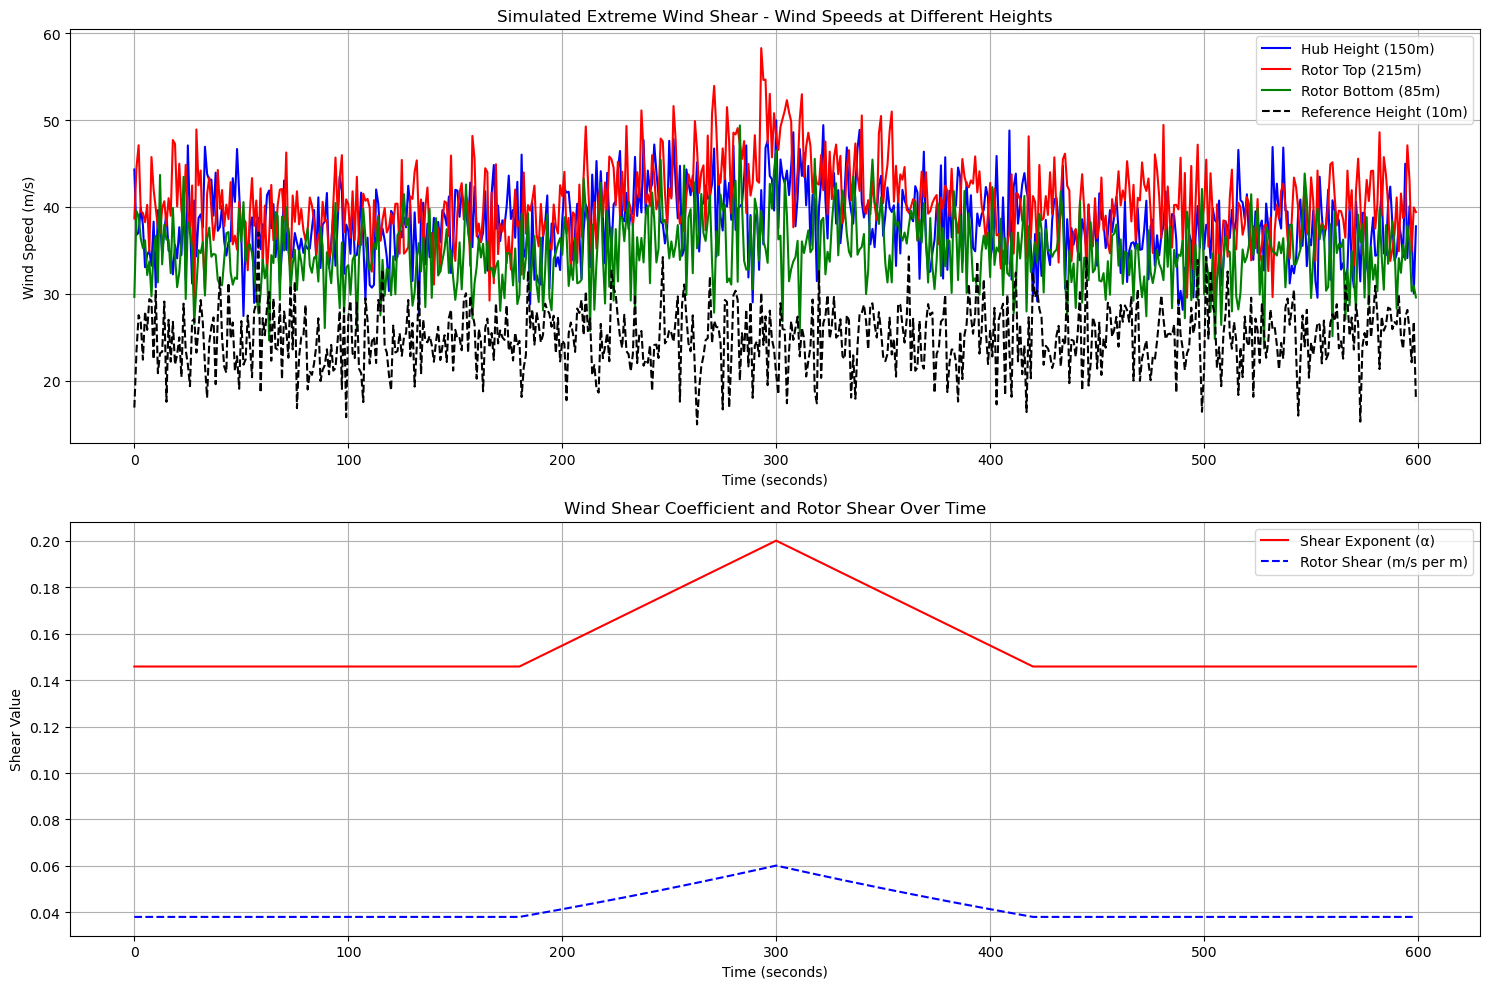

In [70]:
# Simulate extreme wind shear with temporal evolution
shear_simulation = buoy.simulate_extreme_wind_shear(
    base_wind_speed=25,
    duration_minutes=10,
    timestep_seconds=1,
    shear_evolution=True,
    ramp_time_seconds=120
)

# Create plots to visualize the simulated extreme wind shear
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# Plot 1: Wind speeds at different heights
plt.subplot(2, 1, 1)
plt.plot(shear_simulation['time_sec'], shear_simulation['WSPD_150m'], 'b-', label='Hub Height (150m)')
plt.plot(shear_simulation['time_sec'], shear_simulation['WSPD_215m'], 'r-', label='Rotor Top (215m)')
plt.plot(shear_simulation['time_sec'], shear_simulation['WSPD_85m'], 'g-', label='Rotor Bottom (85m)')
plt.plot(shear_simulation['time_sec'], shear_simulation['WSPD_10m'], 'k--', label='Reference Height (10m)')
plt.xlabel('Time (seconds)')
plt.ylabel('Wind Speed (m/s)')
plt.title('Simulated Extreme Wind Shear - Wind Speeds at Different Heights')
plt.legend()
plt.grid(True)

# Plot 2: Wind shear exponent and rotor shear over time
plt.subplot(2, 1, 2)
plt.plot(shear_simulation['time_sec'], shear_simulation['alpha'], 'r-', label='Shear Exponent (α)')
plt.plot(shear_simulation['time_sec'], shear_simulation['rotor_shear'], 'b--', label='Rotor Shear (m/s per m)')
plt.xlabel('Time (seconds)')
plt.ylabel('Shear Value')
plt.title('Wind Shear Coefficient and Rotor Shear Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Time range in simulation: 0 to 599 seconds


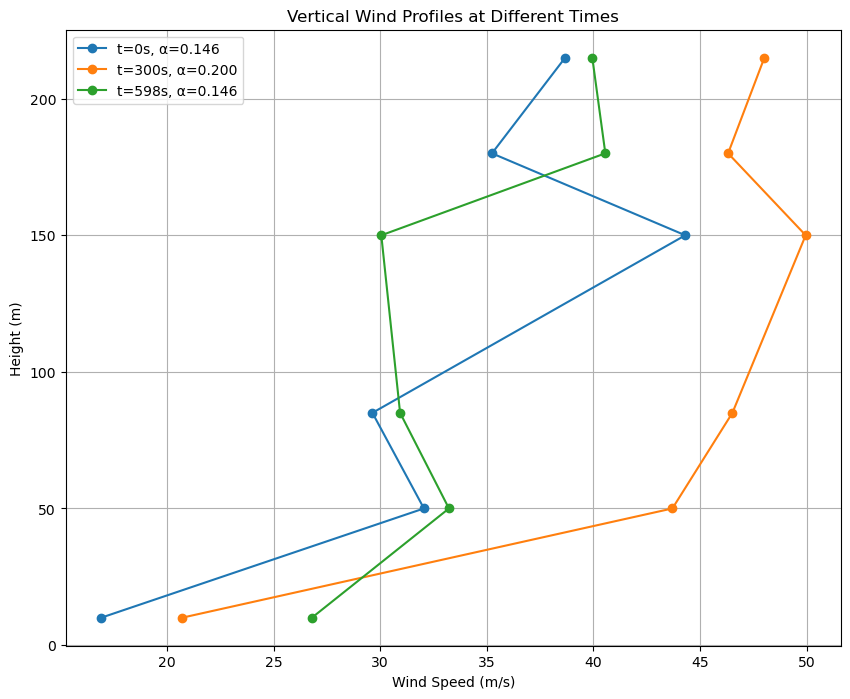


Extreme Wind Shear Statistics:
Maximum shear coefficient (α): 0.200
Maximum rotor shear: 0.060 m/s per meter
Wind speed difference across rotor (max): 26.10 m/s


In [71]:
# Choose time points for vertical profile analysis
min_time = shear_simulation['time_sec'].min()
max_time = shear_simulation['time_sec'].max()
print(f"Time range in simulation: {min_time} to {max_time} seconds")

time_points = [
    min_time,  # beginning
    (min_time + max_time) / 2,  # middle (peak shear)
    max_time - 1  # end (subtract 1 to ensure it's within bounds)
]
heights = [10, 50, 85, 150, 180, 215]

plt.figure(figsize=(10, 8))
for t in time_points:
    idx = shear_simulation['time_sec'].searchsorted(t)
    if idx >= len(shear_simulation):  # Ensure index is within bounds
        idx = len(shear_simulation) - 1
    speeds = [shear_simulation[f'WSPD_{h}m'].iloc[idx] for h in heights]
    plt.plot(speeds, heights, marker='o', label=f't={t:.0f}s, α={shear_simulation["alpha"].iloc[idx]:.3f}')

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Height (m)')
plt.title('Vertical Wind Profiles at Different Times')
plt.legend()
plt.grid(True)
plt.show()

# Calculate and display extreme wind shear statistics
print("\nExtreme Wind Shear Statistics:")
print(f"Maximum shear coefficient (α): {shear_simulation['alpha'].max():.3f}")
print(f"Maximum rotor shear: {shear_simulation['rotor_shear'].max():.3f} m/s per meter")
print(f"Wind speed difference across rotor (max): {(shear_simulation['WSPD_215m'] - shear_simulation['WSPD_85m']).max():.2f} m/s")

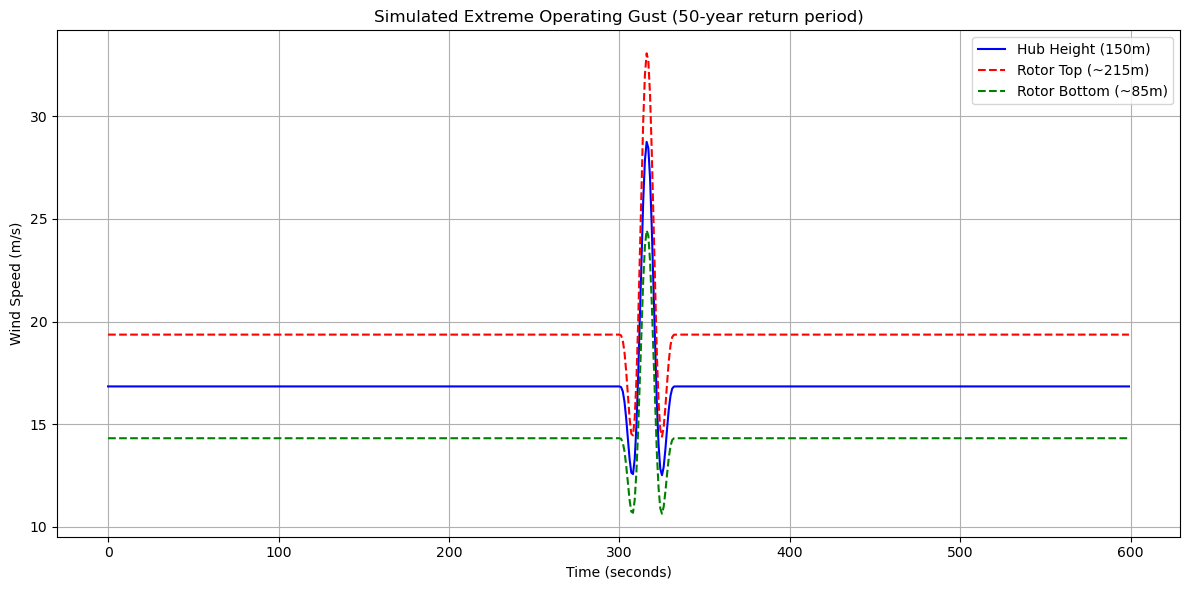


Extreme Gust Statistics:
Reference wind speed: 16.84 m/s
Maximum gust speed: 28.76 m/s
Gust factor: 1.71
Gust amplitude: 16.25 m/s


In [72]:
# Simulate an extreme operating gust scenario for turbine design
gust_simulation = buoy.simulate_extreme_gust(return_period_years=50)

# Plot the simulated extreme gust
plt.figure(figsize=(12, 6))
plt.plot(gust_simulation['time_sec'], gust_simulation['wind_speed'], 'b-', label='Hub Height (150m)')
plt.plot(gust_simulation['time_sec'], gust_simulation['wind_speed_top'], 'r--', label='Rotor Top (~215m)')
plt.plot(gust_simulation['time_sec'], gust_simulation['wind_speed_bottom'], 'g--', label='Rotor Bottom (~85m)')
plt.xlabel('Time (seconds)')
plt.ylabel('Wind Speed (m/s)')
plt.title('Simulated Extreme Operating Gust (50-year return period)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate gust factors and statistics
gust_factor = gust_simulation['wind_speed'].max() / gust_simulation['u_ref'].iloc[0]
gust_amplitude = gust_simulation['wind_speed'].max() - gust_simulation['wind_speed'].min()

print("\nExtreme Gust Statistics:")
print(f"Reference wind speed: {gust_simulation['u_ref'].iloc[0]:.2f} m/s")
print(f"Maximum gust speed: {gust_simulation['wind_speed'].max():.2f} m/s")
print(f"Gust factor: {gust_factor:.2f}")
print(f"Gust amplitude: {gust_amplitude:.2f} m/s")

In [73]:
# Calculate key statistics for wind farm design
extreme_stats = {
    'max_wind_speed_150m': shear_data['WSPD_150m'].max(),
    'max_gust_150m': shear_data['GST_150m'].max(),
    'max_shear_across_rotor': shear_data['rotor_shear'].max(),
    'max_gust_factor': extreme_events['gust_factor'].dropna().max() if len(extreme_events) > 0 else 0
}

print("Extreme wind statistics for turbine design:")
for key, value in extreme_stats.items():
    print(f"  {key}: {value:.2f}")

# Analyze distribution of extreme events by direction
if len(extreme_events) > 0:
    event_stats = buoy.extreme_event_statistics(extreme_events)
    
    print("\nExtreme Event Statistics by Direction:")
    print(event_stats['direction_stats'])
    
    print(f"\nMaximum event duration: {event_stats['max_duration_hours']:.2f} hours")
    print(f"Mean event duration: {event_stats['mean_duration_hours']:.2f} hours")

    # Calculate 50-year extreme wind speed using Gumbel distribution
    ve50 = buoy.calculate_ve50()
    print(f"\n50-year extreme wind speed at hub height: {ve50:.2f} m/s")
else:
    print("\nNo extreme events found in the dataset.")

Extreme wind statistics for turbine design:
  max_wind_speed_150m: 170.16
  max_gust_150m: 170.16
  max_shear_across_rotor: 0.24
  max_gust_factor: 495.00

Extreme Event Statistics by Direction:
                    max       mean  count
WDIR (degT)                              
N            170.158421  53.071085    640
NE           170.158421  71.860412    414
E            170.158421  91.851822    112
SE           170.158421  87.492504    154
S            170.158421  89.078396    158
SW           170.158421  83.856958     81
W            170.158421  59.543441    940
NW           170.158421  60.642720    663

Maximum event duration: 7.00 hours
Mean event duration: 0.72 hours

50-year extreme wind speed at hub height: 309.58 m/s


/var/folders/c9/zx22n7c1713_ck39lvd8nlx00000gn/T/ipykernel_16214/3063825993.py:489: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dir_stats = extreme_events.groupby(dir_sectors)['GST_150m'].agg(['max', 'mean', 'count'])
